# Notebook 01 — Bayes Optimal Classifier
**DSC 240 · Machine Learning · UCSD**

The **Bayes optimal classifier** is the best any algorithm can do — it minimizes expected loss given perfect knowledge of the data distribution. Every other classifier we study is trying to approximate it from data.

In this notebook:
1. Derive and implement the Bayes optimal decision rule
2. Visualize class-conditional densities and the decision boundary
3. Estimate densities empirically (Parzen windows / k-NN)
4. Measure how close each method gets to the Bayes error floor

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {'pos': '#E63946', 'neg': '#457B9D', 'boundary': '#2D6A4F', 'bg': '#f8f9fa'}

## 1. The Decision Rule

**Setup:** $(x, y) \sim P$ where $y \in \{+1, -1\}$.

We want to minimize **expected 0-1 loss**: $\mathbb{E}[\mathbf{1}_{c(x) \neq y}]$.

**Bayes classifier** (compare posteriors):
$$c^*(x) = \begin{cases} +1 & \text{if } P(y=+1 \mid x) > P(y=-1 \mid x) \\ -1 & \text{otherwise} \end{cases}$$

By Bayes' rule this is equivalent to comparing **class-conditional likelihoods**:
$$P(x \mid y=+1) \cdot P(y=+1) \quad \text{vs.} \quad P(x \mid y=-1) \cdot P(y=-1)$$

**Bayes error** = $\mathbb{E}_x[\min(P(y=+1 \mid x),\, P(y=-1 \mid x))]$ — the irreducible floor.

In [2]:
# --- Define the ground-truth distribution ---
# Two Gaussians with known parameters
mu_pos = np.array([1.5,  1.0])
mu_neg = np.array([-1.0, -0.5])
Sigma_pos = np.array([[1.2, 0.4], [0.4, 0.8]])
Sigma_neg = np.array([[0.9, -0.3], [-0.3, 1.1]])
pi_pos = 0.55   # P(y=+1)
pi_neg = 0.45   # P(y=-1)

dist_pos = multivariate_normal(mu_pos, Sigma_pos)
dist_neg = multivariate_normal(mu_neg, Sigma_neg)

def bayes_classify(x):
    """Return +1 or -1 using the exact Bayes rule."""
    score_pos = dist_pos.pdf(x) * pi_pos
    score_neg = dist_neg.pdf(x) * pi_neg
    return np.where(score_pos > score_neg, 1, -1)

def bayes_error_at(x):
    """Pointwise min posterior — contributes to Bayes error."""
    p_pos = dist_pos.pdf(x) * pi_pos
    p_neg = dist_neg.pdf(x) * pi_neg
    p_total = p_pos + p_neg
    # Avoid division by zero
    p_total = np.where(p_total > 1e-12, p_total, 1e-12)
    post_pos = p_pos / p_total
    post_neg = p_neg / p_total
    return np.minimum(post_pos, post_neg) * p_total

## 2. Visualize the Distribution and Bayes Boundary

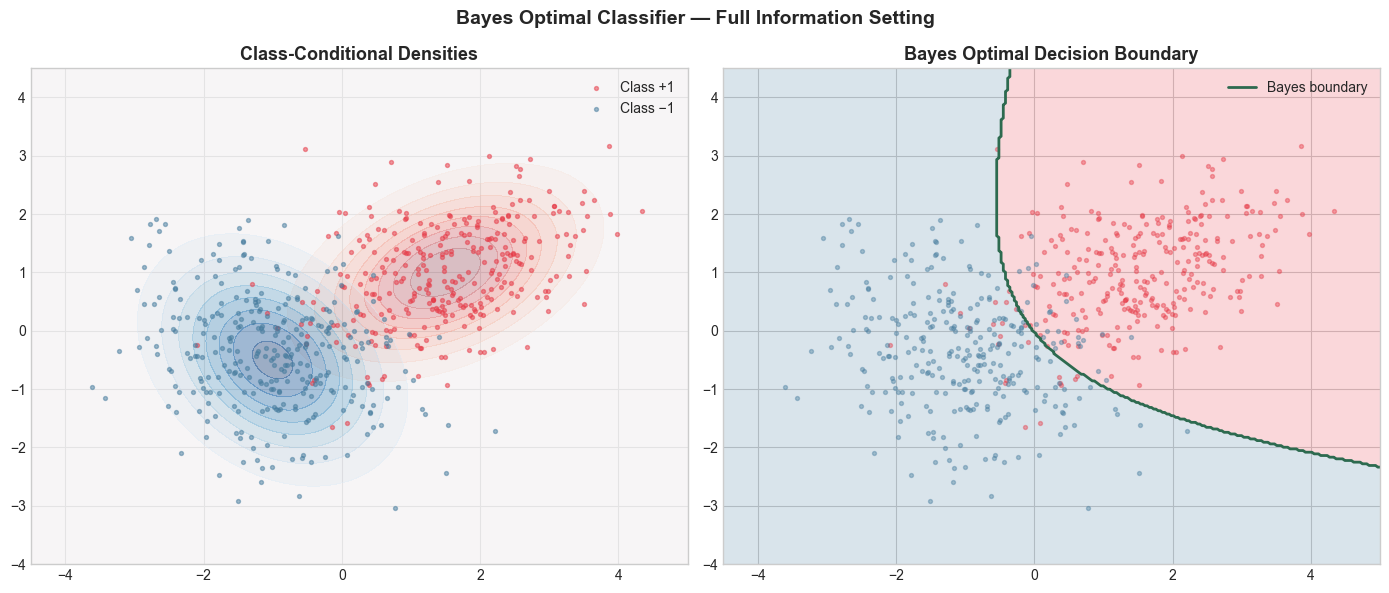

In [3]:
# Build a grid for visualization
xx, yy = np.meshgrid(np.linspace(-4.5, 5, 300), np.linspace(-4, 4.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Bayes decisions on grid
Z_bayes = bayes_classify(grid).reshape(xx.shape)

# Class-conditional densities
dens_pos = dist_pos.pdf(grid).reshape(xx.shape)
dens_neg = dist_neg.pdf(grid).reshape(xx.shape)

# Sample data for illustration
n_each = 300
X_pos_s = np.random.multivariate_normal(mu_pos, Sigma_pos, n_each)
X_neg_s = np.random.multivariate_normal(mu_neg, Sigma_neg, n_each)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: class-conditional densities
ax = axes[0]
ax.contourf(xx, yy, dens_pos, levels=8, cmap='Reds', alpha=0.4)
ax.contourf(xx, yy, dens_neg, levels=8, cmap='Blues', alpha=0.4)
ax.scatter(X_pos_s[:,0], X_pos_s[:,1], c=COLORS['pos'], s=8, alpha=0.5, label='Class +1')
ax.scatter(X_neg_s[:,0], X_neg_s[:,1], c=COLORS['neg'], s=8, alpha=0.5, label='Class −1')
ax.set_title('Class-Conditional Densities', fontsize=13, fontweight='bold')
ax.legend()

# Right: Bayes decision boundary
ax = axes[1]
ax.contourf(xx, yy, Z_bayes, levels=[-2, 0, 2], colors=[COLORS['neg'], COLORS['pos']], alpha=0.2)
ax.contour(xx, yy, Z_bayes, levels=[0], colors=[COLORS['boundary']], linewidths=2)
ax.scatter(X_pos_s[:,0], X_pos_s[:,1], c=COLORS['pos'], s=8, alpha=0.4)
ax.scatter(X_neg_s[:,0], X_neg_s[:,1], c=COLORS['neg'], s=8, alpha=0.4)
ax.set_title('Bayes Optimal Decision Boundary', fontsize=13, fontweight='bold')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color=COLORS['boundary'], lw=2, label='Bayes boundary')])

for a in axes:
    a.set_xlim(-4.5, 5); a.set_ylim(-4, 4.5)

plt.suptitle('Bayes Optimal Classifier — Full Information Setting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/bayes_classifier.png', dpi=120)
plt.show()

## 3. Compute the Bayes Error Floor

In [4]:
# Monte Carlo estimate of Bayes error
# E[min(P(+1|x), P(-1|x))] integrated over the marginal P(x)
n_mc = 100_000
# Sample from marginal: mix of both classes
labels_mc = np.random.choice([1, -1], size=n_mc, p=[pi_pos, pi_neg])
X_mc = np.vstack([
    np.random.multivariate_normal(mu_pos, Sigma_pos, int(pi_pos * n_mc)),
    np.random.multivariate_normal(mu_neg, Sigma_neg, int(pi_neg * n_mc))
])
preds_bayes = bayes_classify(X_mc)
# Error = fraction misclassified under Bayes rule
# (Note: labels_mc and X_mc must be aligned — redo sampling properly)
n_pos = int(pi_pos * n_mc)
n_neg = n_mc - n_pos
y_mc = np.hstack([np.ones(n_pos), -np.ones(n_neg)])
bayes_error_estimate = np.mean(preds_bayes != y_mc)
print(f'Estimated Bayes error: {bayes_error_estimate:.4f}')

Estimated Bayes error: 0.0726


## 4. k-NN: Approaching Bayes from Data

The **k-NN classifier** estimates class posteriors by counting neighbors. Cover & Hart (1967) proved:

> As $n \to \infty$, the 1-NN error is **at most twice the Bayes error**.

This is remarkable — without ever explicitly estimating the density, 1-NN approaches near-optimality.

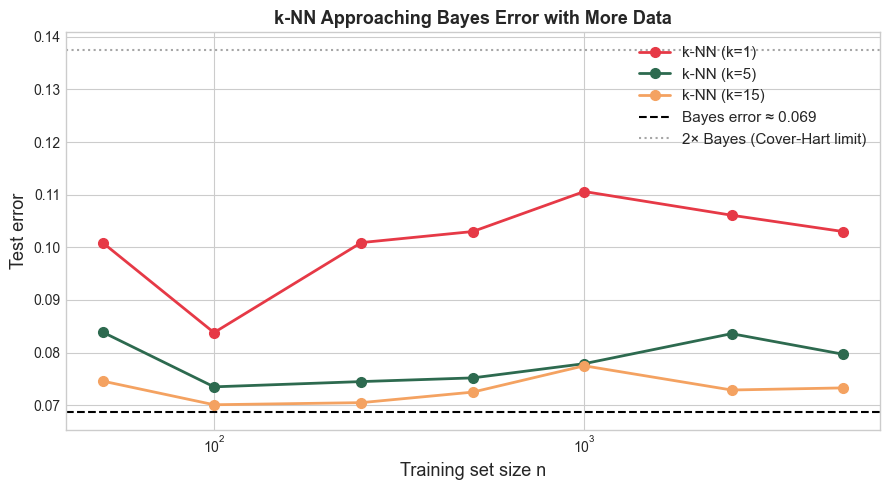

In [5]:
# Build training and test sets
def sample_data(n):
    n_p = int(pi_pos * n)
    n_n = n - n_p
    X = np.vstack([
        np.random.multivariate_normal(mu_pos, Sigma_pos, n_p),
        np.random.multivariate_normal(mu_neg, Sigma_neg, n_n)
    ])
    y = np.hstack([np.ones(n_p), -np.ones(n_n)])
    return X, y

# Vary training set size
ns = [50, 100, 250, 500, 1000, 2500, 5000]
X_test_big, y_test_big = sample_data(10000)
y_test_bayes = bayes_classify(X_test_big)
bayes_test_error = np.mean(y_test_bayes != y_test_big)

knn_errors = {1: [], 5: [], 15: []}
for n in ns:
    X_tr, y_tr = sample_data(n)
    for k in knn_errors:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_tr, y_tr)
        err = 1 - clf.score(X_test_big, y_test_big)
        knn_errors[k].append(err)

fig, ax = plt.subplots(figsize=(9, 5))
colors_knn = ['#E63946', '#2D6A4F', '#F4A261']
for (k, errs), c in zip(knn_errors.items(), colors_knn):
    ax.semilogx(ns, errs, '-o', color=c, lw=2, ms=7, label=f'k-NN (k={k})')
ax.axhline(bayes_test_error, color='black', ls='--', lw=1.5, label=f'Bayes error ≈ {bayes_test_error:.3f}')
ax.axhline(2*bayes_test_error, color='gray', ls=':', lw=1.5, alpha=0.7, label='2× Bayes (Cover-Hart limit)')

ax.set_xlabel('Training set size n', fontsize=13)
ax.set_ylabel('Test error', fontsize=13)
ax.set_title('k-NN Approaching Bayes Error with More Data', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../assets/figures/knn_vs_bayes.png', dpi=120)
plt.show()

## Summary

| Method | Knowledge required | Error bound |
|--------|-------------------|-------------|
| Bayes optimal | Full distribution P(x,y) | Bayes error $\epsilon^*$ (floor) |
| 1-NN | Only training data | ≤ 2ε* (Cover & Hart, 1967) |
| k-NN (k→∞, n→∞) | Training data | → ε* |

**Next:** The Perceptron — a simple algorithm for finding linear decision boundaries (`02_perceptron.ipynb`).